# Supply Chain Data Warehouse — EDA
**10 Tables | 35 Questions**

Tables: `dim_customer`, `dim_date`, `dim_facility`, `dim_product`, `dim_supplier`, `fact_inventory`, `fact_procurement`, `fact_production`, `fact_sales`, `fact_shipment`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dim_customer     = pd.read_csv('data/dim_customer.csv')
dim_date         = pd.read_csv('data/dim_date.csv')
dim_facility     = pd.read_csv('data/dim_facility.csv')
dim_product      = pd.read_csv('data/dim_product.csv')
dim_supplier     = pd.read_csv('data/dim_supplier.csv')
fact_inventory   = pd.read_csv('data/fact_inventory.csv')
fact_procurement = pd.read_csv('data/fact_procurement.csv')
fact_production  = pd.read_csv('data/fact_production.csv')
fact_sales       = pd.read_csv('data/fact_sales.csv')
fact_shipment    = pd.read_csv('data/fact_shipment.csv')

---
## Section 1 — Dimension Tables Overview
### Q1. What does each dimension table look like? (head + shape)

In [3]:
dims = {'dim_customer': dim_customer, 'dim_date': dim_date,
        'dim_facility': dim_facility, 'dim_product': dim_product,
        'dim_supplier': dim_supplier}

for name, df in dims.items():
    print(f'\n=== {name} | shape: {df.shape} ===')
    print(df.head(3))


=== dim_customer | shape: (5, 7) ===
   customer_id customer_key    customer_name  country channel_type    size  \
0            1     CUST-001  TechMart Global      USA       Online   Large   
1            2     CUST-002    RetailHub Inc  Germany       Retail  Medium   
2            3     CUST-003     MegaStore Co       UK    Wholesale   Large   

   annual_volume_usd  
0            5200000  
1            1800000  
2            7500000  

=== dim_date | shape: (2192, 11) ===
   date_key        date  year  quarter  month month_name  week  day  \
0         1  2019-01-01  2019        1      1    January     1    1   
1         2  2019-01-02  2019        1      1    January     1    2   
2         3  2019-01-03  2019        1      1    January     1    3   

   day_of_week   day_name  is_weekend  
0            1    Tuesday       False  
1            2  Wednesday       False  
2            3   Thursday       False  

=== dim_facility | shape: (5, 8) ===
   facility_id facility_key       fa

### Q2. How many unique customers are there per country?

country
USA          1
Germany      1
UK           1
Canada       1
Australia    1
Name: count, dtype: int64


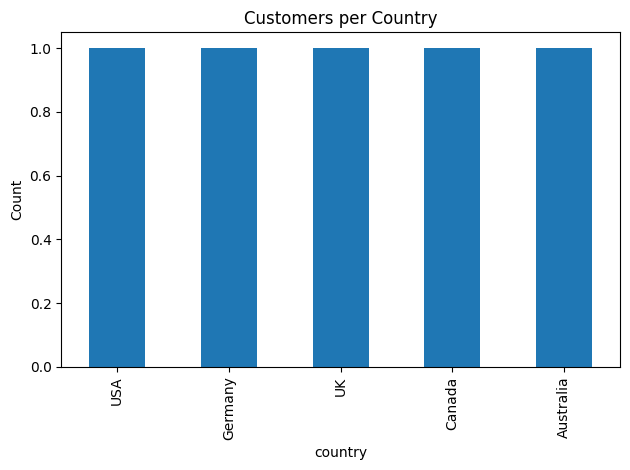

In [4]:
country_counts = dim_customer['country'].value_counts()
print(country_counts)

country_counts.plot(kind='bar', title='Customers per Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Q3. What is the distribution of customer sizes?

size
Large     2
Medium    2
Small     1
Name: count, dtype: int64


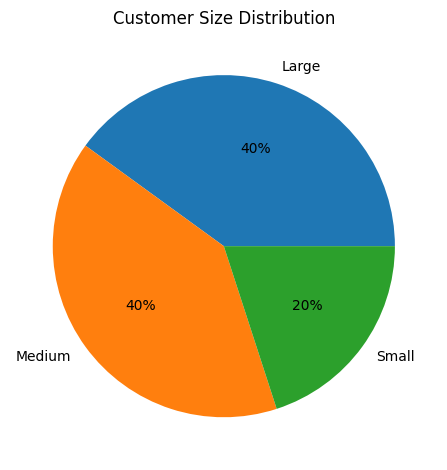

In [5]:
size_counts = dim_customer['size'].value_counts()
print(size_counts)

size_counts.plot(kind='pie', autopct='%1.0f%%', title='Customer Size Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Q4. What are the top 10 customers by annual volume?

     customer_name  annual_volume_usd
2     MegaStore Co            7500000
0  TechMart Global            5200000
4  ValueChain Corp            2100000
1    RetailHub Inc            1800000
3    QuickShop Ltd             450000


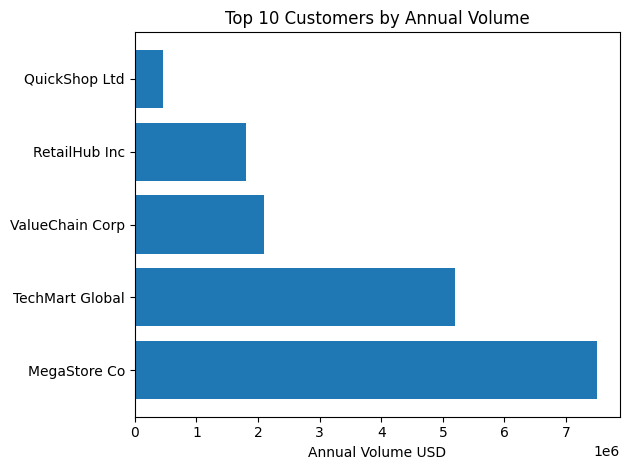

In [6]:
top10 = dim_customer.nlargest(10, 'annual_volume_usd')[['customer_name', 'annual_volume_usd']]
print(top10)

plt.barh(top10['customer_name'], top10['annual_volume_usd'])
plt.xlabel('Annual Volume USD')
plt.title('Top 10 Customers by Annual Volume')
plt.tight_layout()
plt.show()

### Q5. What product categories exist and how many products are in each?

category
Electronics    5
Furniture      4
Apparel        4
Home Goods     4
Tools          3
Name: count, dtype: int64


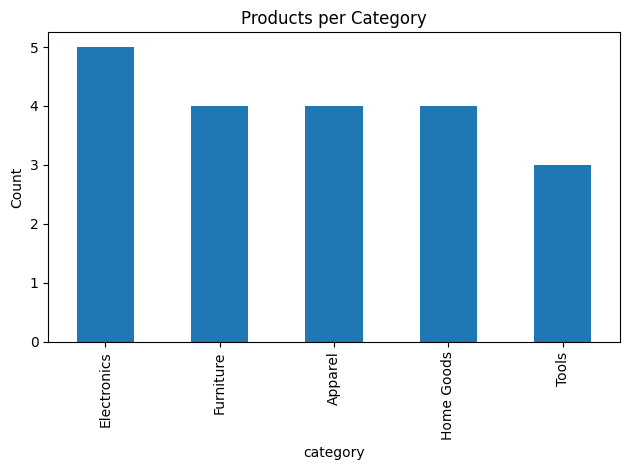

In [7]:
cat_counts = dim_product['category'].value_counts()
print(cat_counts)

cat_counts.plot(kind='bar', title='Products per Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Q6. What is the average unit price and unit cost per product category?

             unit_price  unit_cost
category                          
Apparel           71.25      32.75
Electronics      359.00     201.00
Furniture        420.00     192.50
Home Goods        57.50      24.50
Tools            155.00      75.00


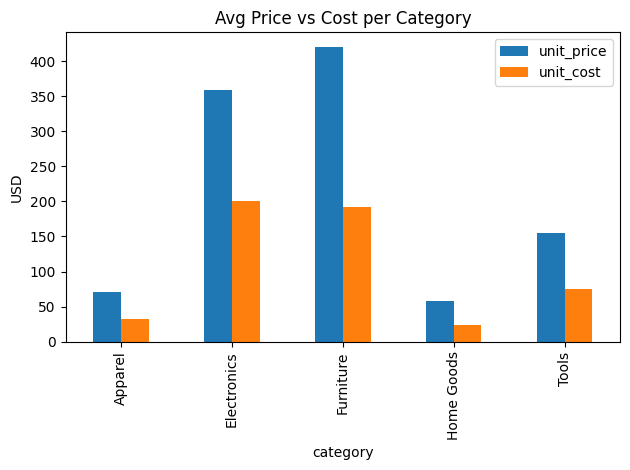

In [8]:
price_cost = dim_product.groupby('category')[['unit_price', 'unit_cost']].mean().round(2)
print(price_cost)

price_cost.plot(kind='bar', title='Avg Price vs Cost per Category')
plt.ylabel('USD')
plt.tight_layout()
plt.show()

### Q7. How many suppliers are there per tier and per country?

--- Suppliers per Tier ---
tier
1    4
2    4
3    2
Name: count, dtype: int64

--- Suppliers per Country ---
country
China          1
USA            1
Germany        1
Japan          1
India          1
Mexico         1
South Korea    1
Taiwan         1
Brazil         1
UK             1
Name: count, dtype: int64


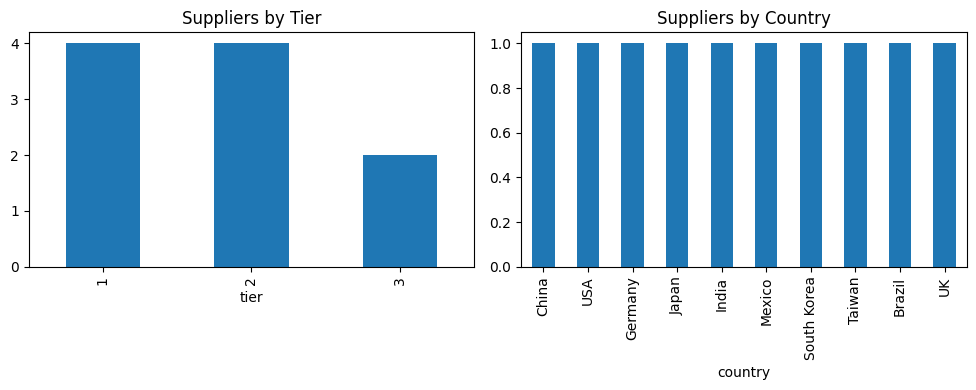

In [9]:
print('--- Suppliers per Tier ---')
print(dim_supplier['tier'].value_counts())

print('\n--- Suppliers per Country ---')
print(dim_supplier['country'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
dim_supplier['tier'].value_counts().plot(kind='bar', ax=axes[0], title='Suppliers by Tier')
dim_supplier['country'].value_counts().plot(kind='bar', ax=axes[1], title='Suppliers by Country')
plt.tight_layout()
plt.show()

---
## Section 2 — Sales Analysis
### Q8. What is the total gross revenue, net revenue, and profit overall?

Gross Revenue : $568,300,720.00
Net Revenue   : $527,401,355.75
Total Profit  : $243,217,776.75


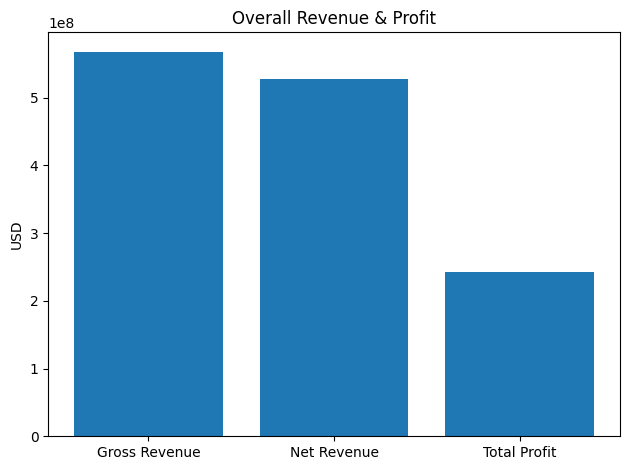

In [10]:
total_gross  = fact_sales['gross_revenue'].sum()
total_net    = fact_sales['net_revenue'].sum()
total_profit = fact_sales['profit'].sum()

print(f'Gross Revenue : ${total_gross:,.2f}')
print(f'Net Revenue   : ${total_net:,.2f}')
print(f'Total Profit  : ${total_profit:,.2f}')

plt.bar(['Gross Revenue', 'Net Revenue', 'Total Profit'], [total_gross, total_net, total_profit])
plt.ylabel('USD')
plt.title('Overall Revenue & Profit')
plt.tight_layout()
plt.show()

### Q9. What is the monthly net revenue trend?

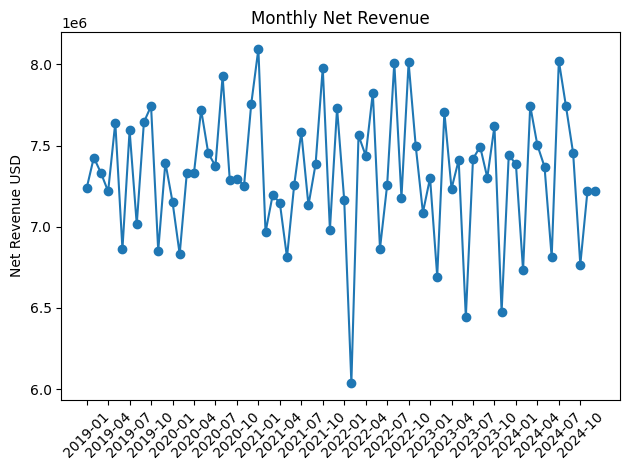

In [13]:
sales_date = fact_sales.merge(dim_date[['date_key', 'year', 'month']], on='date_key')
monthly_rev = sales_date.groupby(['year', 'month'])['net_revenue'].sum().reset_index()
monthly_rev['period'] = monthly_rev['year'].astype(str) + '-' + monthly_rev['month'].astype(str).str.zfill(2)
monthly_rev = monthly_rev.sort_values('period')

plt.plot(monthly_rev['period'], monthly_rev['net_revenue'], marker='o')
plt.xticks(ticks=range(0, len(monthly_rev['period']), 3), rotation=45)
plt.title('Monthly Net Revenue')
plt.ylabel('Net Revenue USD')
plt.tight_layout()
plt.show()

### Q10. Which product category generates the most profit?

category
Furniture      1.010081e+08
Electronics    8.422696e+07
Tools          2.605393e+07
Apparel        1.704900e+07
Home Goods     1.487983e+07
Name: profit, dtype: float64


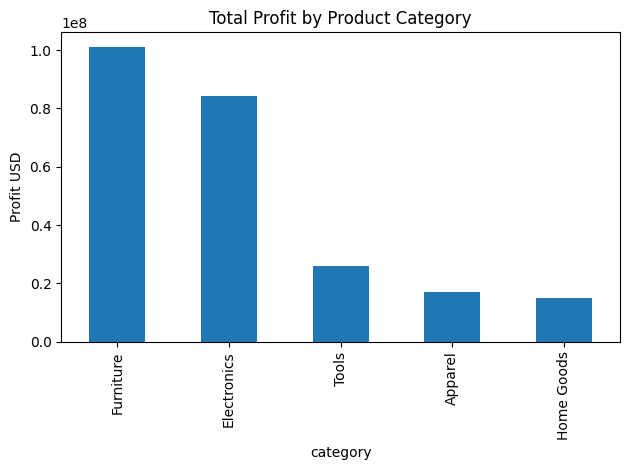

In [14]:
sales_prod = fact_sales.merge(dim_product[['product_id', 'category']], on='product_id')
cat_profit = sales_prod.groupby('category')['profit'].sum().sort_values(ascending=False)
print(cat_profit)

cat_profit.plot(kind='bar', title='Total Profit by Product Category')
plt.ylabel('Profit USD')
plt.tight_layout()
plt.show()

### Q11. What is the average profit margin per product line?

product_line
Bedroom          55.08
Casual           54.44
Kitchen          54.11
Home             52.05
Office           50.16
Hand Tools       49.93
Sport            49.30
Professional     48.84
Power Tools      47.24
Consumer Tech    46.25
Name: profit_margin_pct, dtype: float64


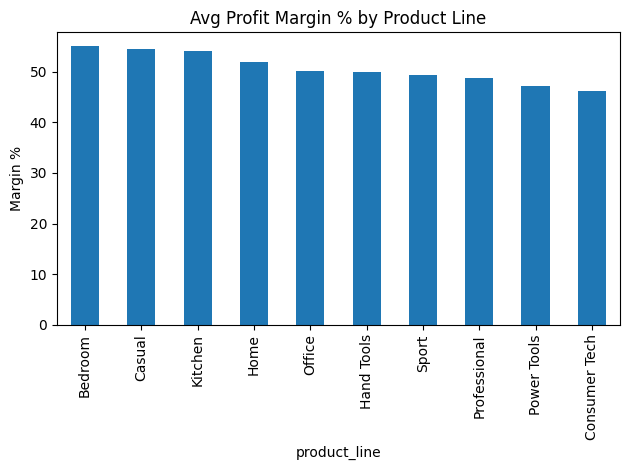

In [15]:
sales_pl = fact_sales.merge(dim_product[['product_id', 'product_line']], on='product_id')
margin_pl = sales_pl.groupby('product_line')['profit_margin_pct'].mean().round(2).sort_values(ascending=False)
print(margin_pl)

margin_pl.plot(kind='bar', title='Avg Profit Margin % by Product Line')
plt.ylabel('Margin %')
plt.tight_layout()
plt.show()

### Q12. Which channel type brings in the highest net revenue?

channel_type
Retail       2.141305e+08
Online       2.081546e+08
Wholesale    1.051162e+08
Name: net_revenue, dtype: float64


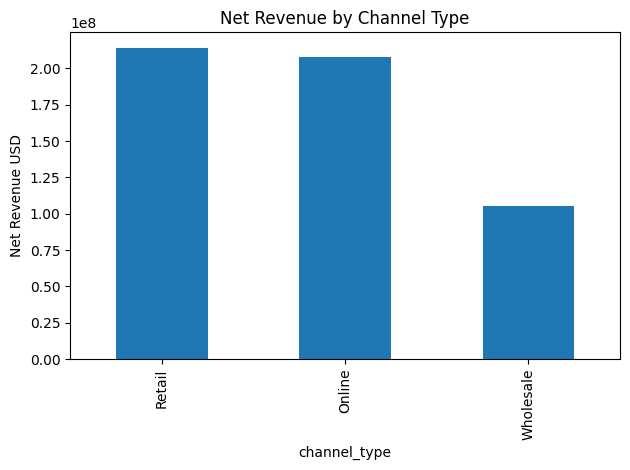

In [16]:
sales_cust = fact_sales.merge(dim_customer[['customer_id', 'channel_type']], on='customer_id')
channel_rev = sales_cust.groupby('channel_type')['net_revenue'].sum().sort_values(ascending=False)
print(channel_rev)

channel_rev.plot(kind='bar', title='Net Revenue by Channel Type')
plt.ylabel('Net Revenue USD')
plt.tight_layout()
plt.show()

### Q13. What is the distribution of discount percentages applied on sales?

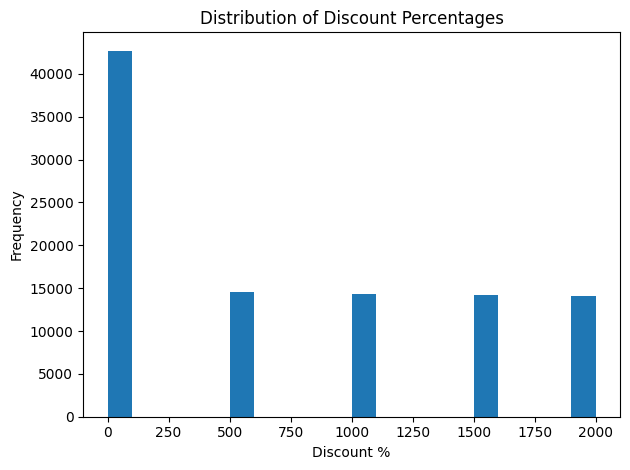

count    100000.000000
mean          7.126000
std           7.468948
min           0.000000
25%           0.000000
50%           5.000000
75%          15.000000
max          20.000000
Name: discount_pct, dtype: float64


In [17]:
plt.hist(fact_sales['discount_pct'] * 100, bins=20)
plt.xlabel('Discount %')
plt.ylabel('Frequency')
plt.title('Distribution of Discount Percentages')
plt.tight_layout()
plt.show()

print(fact_sales['discount_pct'].describe())

### Q14. Which top 5 customers have the highest total net revenue?

customer_name
RetailHub Inc      1.094891e+08
MegaStore Co       1.051162e+08
ValueChain Corp    1.046414e+08
TechMart Global    1.042761e+08
QuickShop Ltd      1.038786e+08
Name: net_revenue, dtype: float64


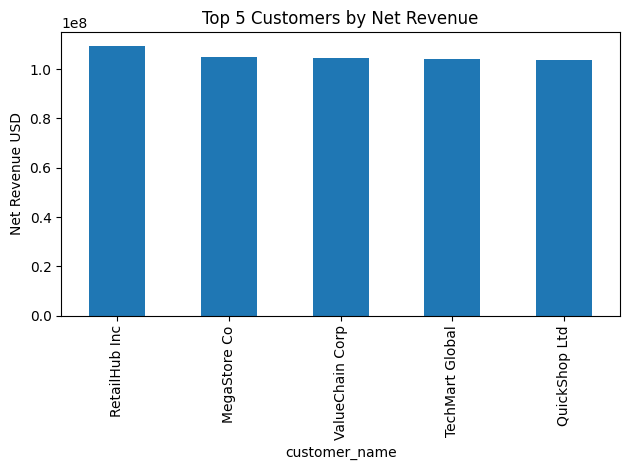

In [18]:
sales_cname = fact_sales.merge(dim_customer[['customer_id', 'customer_name']], on='customer_id')
top5_cust = sales_cname.groupby('customer_name')['net_revenue'].sum().nlargest(5)
print(top5_cust)

top5_cust.plot(kind='bar', title='Top 5 Customers by Net Revenue')
plt.ylabel('Net Revenue USD')
plt.tight_layout()
plt.show()

---
## Section 3 — Inventory Analysis
### Q15. How many inventory records have stock below the safety stock level?

In [19]:
below_safety = fact_inventory[fact_inventory['stock_level'] < fact_inventory['safety_stock_level']]
print(f'Records below safety stock : {len(below_safety)}')
print(f'Total inventory records    : {len(fact_inventory)}')
print(f'Percentage                 : {len(below_safety)/len(fact_inventory)*100:.1f}%')

Records below safety stock : 1152
Total inventory records    : 8000
Percentage                 : 14.4%


### Q16. What is the average stock level per facility?

facility_name
North Plant           1043.874282
South Distribution    1008.442156
Central Hub            998.583016
East Warehouse         997.534169
West Assembly          977.540087
Name: stock_level, dtype: float64


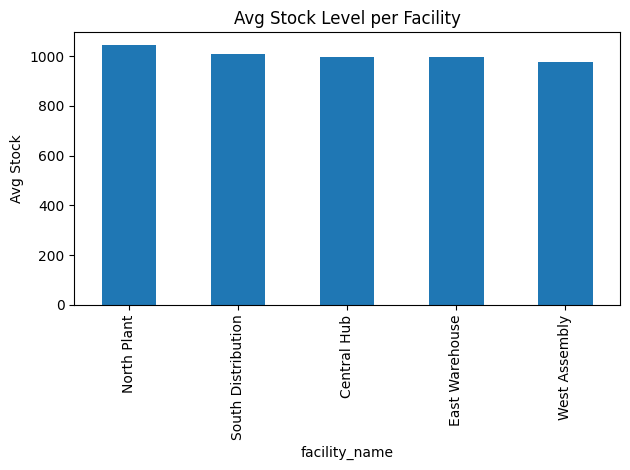

In [20]:
inv_fac = fact_inventory.merge(dim_facility[['facility_id', 'facility_name']], on='facility_id')
avg_stock = inv_fac.groupby('facility_name')['stock_level'].mean().sort_values(ascending=False)
print(avg_stock)

avg_stock.plot(kind='bar', title='Avg Stock Level per Facility')
plt.ylabel('Avg Stock')
plt.tight_layout()
plt.show()

### Q17. Which products are most frequently below their reorder point?

product_name
Sport Leggings         86
Cordless Drill         84
Denim Jacket           82
Memory Foam Pillow     81
Standing Desk          77
Circular Saw           77
Mechanical Keyboard    76
Running Shoes          76
Blender Pro            74
Bookshelf Unit         73
Name: count, dtype: int64


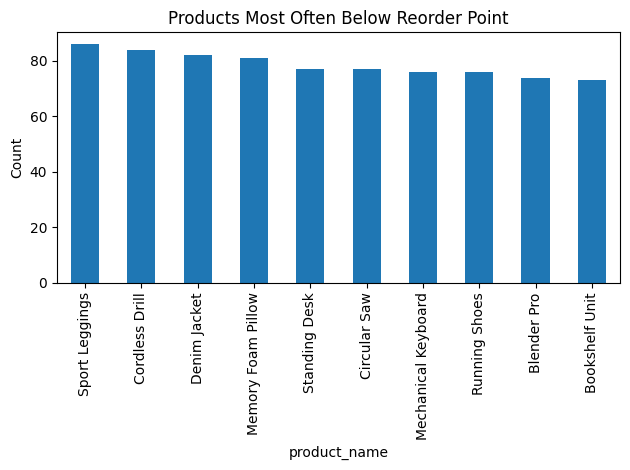

In [21]:
below_reorder = fact_inventory[fact_inventory['stock_level'] < fact_inventory['reorder_point']]
below_reorder_prod = below_reorder.merge(dim_product[['product_id', 'product_name']], on='product_id')
top_reorder = below_reorder_prod['product_name'].value_counts().head(10)
print(top_reorder)

top_reorder.plot(kind='bar', title='Products Most Often Below Reorder Point')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Q18. What is the stock level distribution across all facilities?

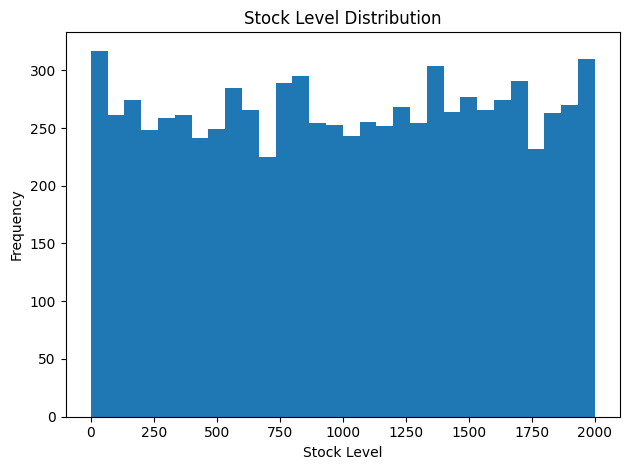

count    8000.000000
mean     1005.047750
std       584.267176
min         0.000000
25%       503.000000
50%      1007.500000
75%      1512.000000
max      2000.000000
Name: stock_level, dtype: float64


In [22]:
plt.hist(fact_inventory['stock_level'], bins=30)
plt.xlabel('Stock Level')
plt.ylabel('Frequency')
plt.title('Stock Level Distribution')
plt.tight_layout()
plt.show()

print(fact_inventory['stock_level'].describe())

---
## Section 4 — Procurement Analysis
### Q19. What is the total procurement spend per supplier?

supplier_name
DeltaParts Ltd        19883194.26
EtaIndustries         18880597.35
AlphaRaw Materials    18606120.26
GammaSupply Co        17181671.17
KappaTraders          16673226.83
IotaVendors Inc       16557001.34
ZetaSource LLC        16520683.56
BetaComponents Inc    16229427.15
EpsilonGoods Corp     14139640.46
ThetaLogistics        13659582.28
Name: total_cost, dtype: float64


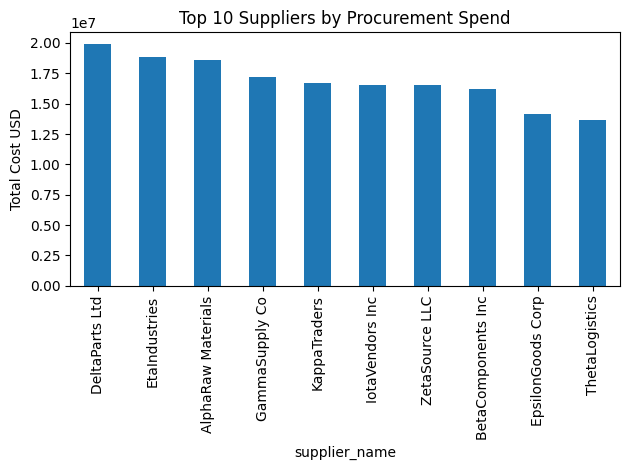

In [23]:
proc_sup = fact_procurement.merge(dim_supplier[['supplier_id', 'supplier_name']], on='supplier_id')
spend_sup = proc_sup.groupby('supplier_name')['total_cost'].sum().sort_values(ascending=False).head(10)
print(spend_sup)

spend_sup.plot(kind='bar', title='Top 10 Suppliers by Procurement Spend')
plt.ylabel('Total Cost USD')
plt.tight_layout()
plt.show()

### Q20. What is the average lead time per supplier tier?

tier
1    32.5
2    32.9
3    33.3
Name: lead_time_days, dtype: float64


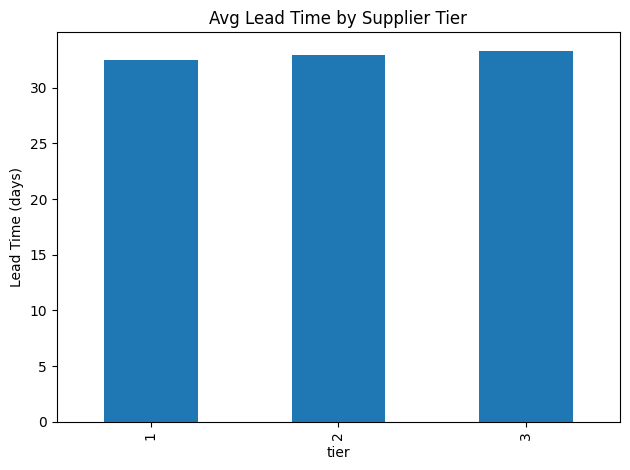

In [24]:
proc_tier = fact_procurement.merge(dim_supplier[['supplier_id', 'tier']], on='supplier_id')
avg_lead = proc_tier.groupby('tier')['lead_time_days'].mean().round(1)
print(avg_lead)

avg_lead.plot(kind='bar', title='Avg Lead Time by Supplier Tier')
plt.ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

### Q21. What is the quality score distribution from all procurement orders?

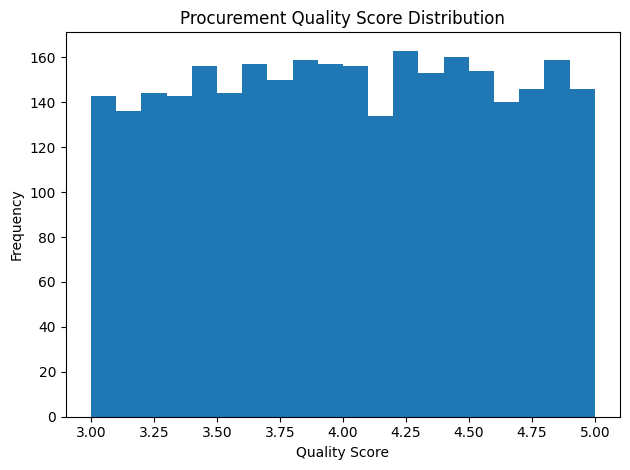

count    3000.00000
mean        4.00453
std         0.57036
min         3.00000
25%         3.52000
50%         4.00000
75%         4.49000
max         5.00000
Name: quality_score, dtype: float64


In [25]:
plt.hist(fact_procurement['quality_score'], bins=20)
plt.xlabel('Quality Score')
plt.ylabel('Frequency')
plt.title('Procurement Quality Score Distribution')
plt.tight_layout()
plt.show()

print(fact_procurement['quality_score'].describe())

### Q22. Which product has the highest total procurement cost?

product_name
Laptop Pro 15          54773930.75
Standing Desk          30084711.08
Ergonomic Chair        16492020.13
Monitor 27"            13265980.31
Circular Saw            8230285.04
Bookshelf Unit          7097475.61
Cordless Drill          6165385.07
Coffee Table            4983111.17
Running Shoes           3909905.93
Mechanical Keyboard     3891202.84
Name: total_cost, dtype: float64


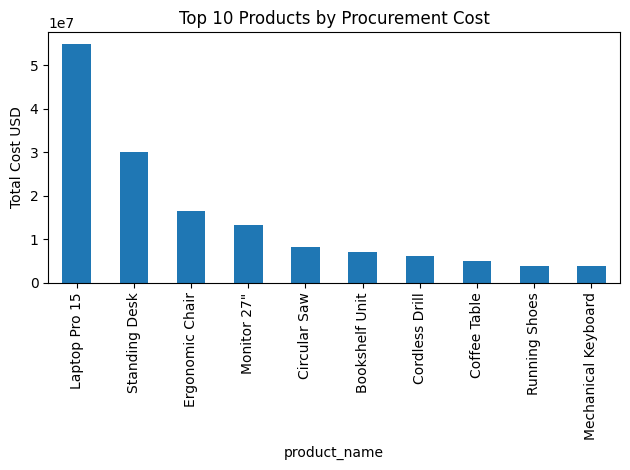

In [26]:
proc_prod = fact_procurement.merge(dim_product[['product_id', 'product_name']], on='product_id')
top_proc_prod = proc_prod.groupby('product_name')['total_cost'].sum().nlargest(10)
print(top_proc_prod)

top_proc_prod.plot(kind='bar', title='Top 10 Products by Procurement Cost')
plt.ylabel('Total Cost USD')
plt.tight_layout()
plt.show()

---
## Section 5 — Production Analysis
### Q23. What is the total quantity produced per facility?

facility_name
West Assembly         1025674
East Warehouse        1002007
South Distribution     976742
North Plant            970397
Central Hub            962840
Name: quantity_produced, dtype: int64


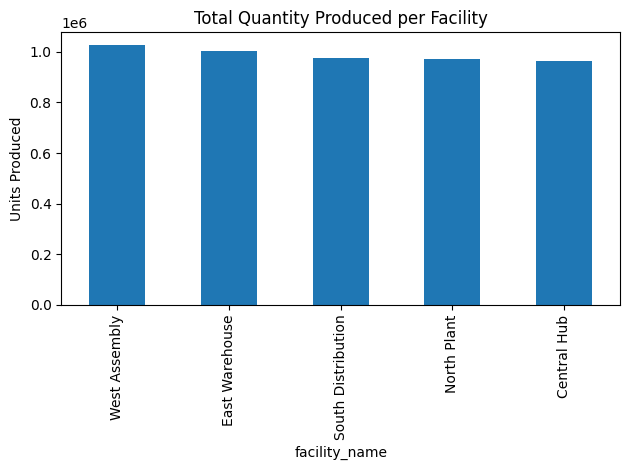

In [27]:
prod_fac = fact_production.merge(dim_facility[['facility_id', 'facility_name']], on='facility_id')
total_produced = prod_fac.groupby('facility_name')['quantity_produced'].sum().sort_values(ascending=False)
print(total_produced)

total_produced.plot(kind='bar', title='Total Quantity Produced per Facility')
plt.ylabel('Units Produced')
plt.tight_layout()
plt.show()

### Q24. Which facility has the highest average defect rate?

facility_name
Central Hub           2.522248
West Assembly         2.521237
South Distribution    2.518661
East Warehouse        2.497994
North Plant           2.482198
Name: defect_rate_pct, dtype: float64


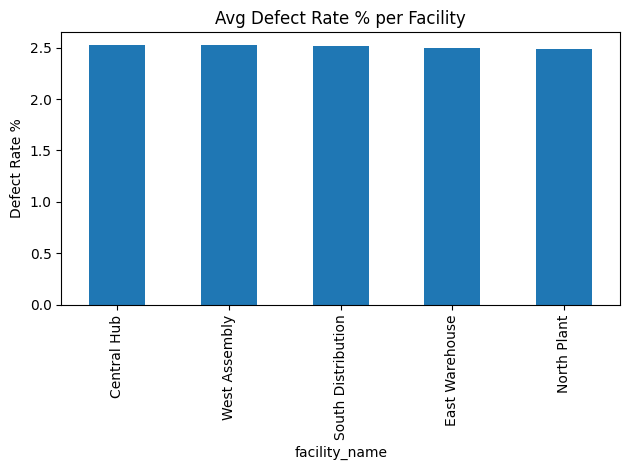

In [28]:
defect_fac = prod_fac.groupby('facility_name')['defect_rate_pct'].mean().sort_values(ascending=False)
print(defect_fac)

defect_fac.plot(kind='bar', title='Avg Defect Rate % per Facility')
plt.ylabel('Defect Rate %')
plt.tight_layout()
plt.show()

### Q25. What is the overall defect rate trend over time (monthly)?

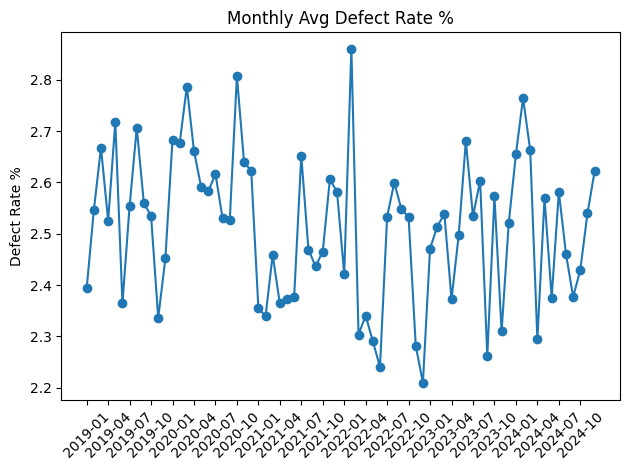

In [30]:
prod_date = fact_production.merge(dim_date[['date_key', 'year', 'month']], on='date_key')
monthly_defect = prod_date.groupby(['year', 'month'])['defect_rate_pct'].mean().reset_index()
monthly_defect['period'] = monthly_defect['year'].astype(str) + '-' + monthly_defect['month'].astype(str).str.zfill(2)
monthly_defect = monthly_defect.sort_values('period')

plt.plot(monthly_defect['period'], monthly_defect['defect_rate_pct'], marker='o')
plt.xticks(ticks=range(0, len(monthly_rev['period']), 3), rotation=45)
plt.title('Monthly Avg Defect Rate %')
plt.ylabel('Defect Rate %')
plt.tight_layout()
plt.show()

### Q26. Which product has the highest total defective units produced?

product_name
Non-Stick Pan         6924
Standing Desk         6864
Monitor 27"           6845
Weighted Blanket      6822
Cordless Drill        6536
Circular Saw          6428
Blender Pro           6382
Wireless Mouse        6340
Wrench Set            6313
Memory Foam Pillow    6213
Name: defective_units, dtype: int64


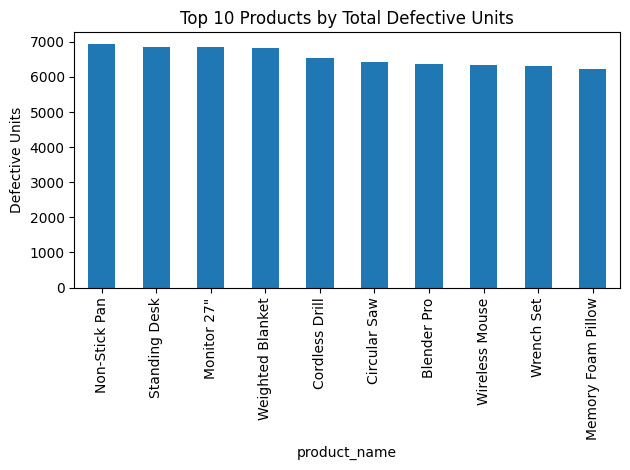

In [31]:
prod_prodname = fact_production.merge(dim_product[['product_id', 'product_name']], on='product_id')
top_defects = prod_prodname.groupby('product_name')['defective_units'].sum().nlargest(10)
print(top_defects)

top_defects.plot(kind='bar', title='Top 10 Products by Total Defective Units')
plt.ylabel('Defective Units')
plt.tight_layout()
plt.show()

---
## Section 6 — Shipment Analysis
### Q27. What is the breakdown of shipment statuses?

status
Delivered     6006
Delayed       2070
Returned      1971
In Transit    1953
Name: count, dtype: int64


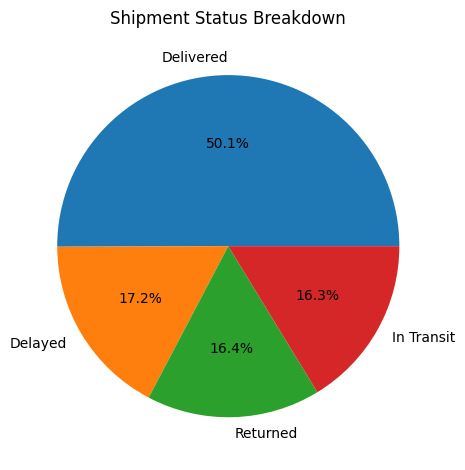

In [32]:
status_counts = fact_shipment['status'].value_counts()
print(status_counts)

status_counts.plot(kind='pie', autopct='%1.1f%%', title='Shipment Status Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Q28. Which carrier handles the most shipments and has the highest shipping cost?

Shipments per Carrier:
carrier
Amazon Logistics    2440
FedEx               2410
USPS                2392
UPS                 2380
DHL                 2378
Name: count, dtype: int64

Total Shipping Cost per Carrier:
carrier
Amazon Logistics    619933.67
FedEx               606637.38
USPS                604531.07
UPS                 602466.85
DHL                 595103.62
Name: shipping_cost, dtype: float64


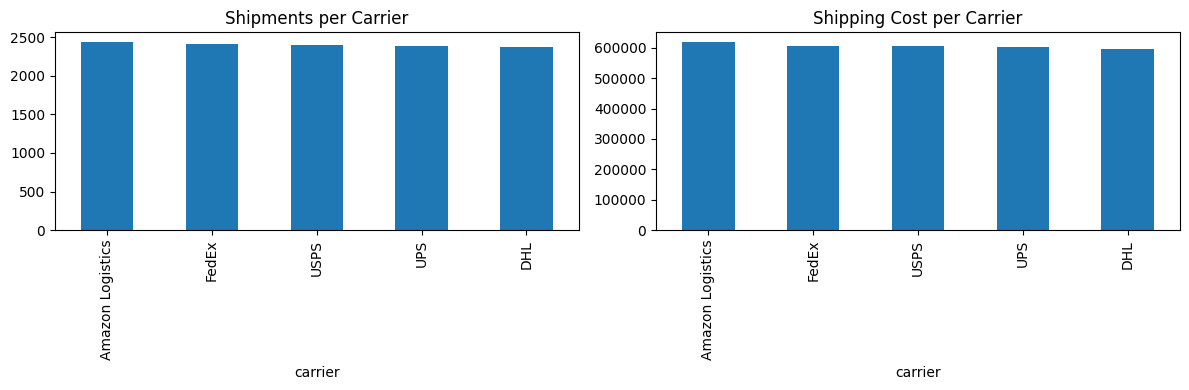

In [33]:
carrier_count = fact_shipment['carrier'].value_counts()
carrier_cost  = fact_shipment.groupby('carrier')['shipping_cost'].sum().sort_values(ascending=False)

print('Shipments per Carrier:')
print(carrier_count)
print('\nTotal Shipping Cost per Carrier:')
print(carrier_cost)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
carrier_count.plot(kind='bar', ax=axes[0], title='Shipments per Carrier')
carrier_cost.plot(kind='bar',  ax=axes[1], title='Shipping Cost per Carrier')
plt.tight_layout()
plt.show()

### Q29. What are the most common reasons for delayed shipments?

delay_reason
Carrier Delay    427
Address Issue    427
Weather          408
Customs          399
Name: count, dtype: int64


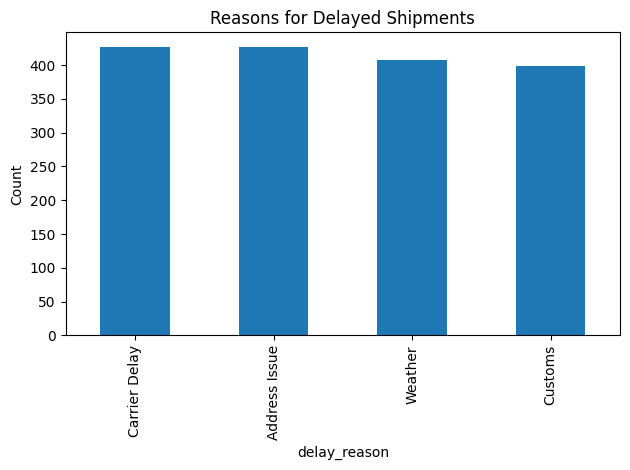

In [34]:
delayed = fact_shipment[fact_shipment['status'] == 'Delayed']
delay_reasons = delayed['delay_reason'].value_counts()
print(delay_reasons)

delay_reasons.plot(kind='bar', title='Reasons for Delayed Shipments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Q30. What is the total shipping cost per customer country?

country
Canada       609725.16
UK           609193.90
Australia    607431.93
USA          602928.95
Germany      599392.65
Name: shipping_cost, dtype: float64


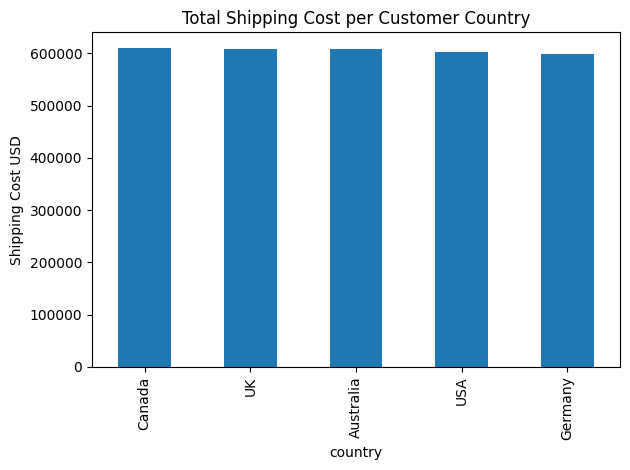

In [35]:
ship_cust = fact_shipment.merge(dim_customer[['customer_id', 'country']], on='customer_id')
country_ship_cost = ship_cust.groupby('country')['shipping_cost'].sum().sort_values(ascending=False)
print(country_ship_cost)

country_ship_cost.plot(kind='bar', title='Total Shipping Cost per Customer Country')
plt.ylabel('Shipping Cost USD')
plt.tight_layout()
plt.show()

---
## Section 7 — Cross-Table Analysis
### Q31. What is the quarterly sales performance (revenue & profit) for each year?

              net_revenue       profit
year quarter                          
2019 1        21995616.25  10100880.25
     2        21723111.75   9997586.75
     3        22253107.00  10255472.00
     4        21992389.00  10161440.00
2020 1        21316350.25   9833681.25
     2        22505659.00  10349181.00
     3        22592416.00  10425862.00
     4        22305376.75  10276349.75
2021 1        22257318.75  10277943.75
     2        21214291.50   9785120.50
     3        22101979.75  10162737.75
     4        22692609.25  10517068.25
2022 1        20765323.25   9604585.25
     2        22130870.75  10208352.75
     3        22447495.00  10321961.00
     4        22596076.75  10355186.75
2023 1        21700955.25  10032906.25
     2        21088449.75   9749686.75
     3        22214653.75  10273788.75
     4        21536218.25   9940286.25
2024 1        21863313.50  10029133.50
     2        21684809.00  10034396.00
     3        23217667.75  10689597.75
     4        21205297.50

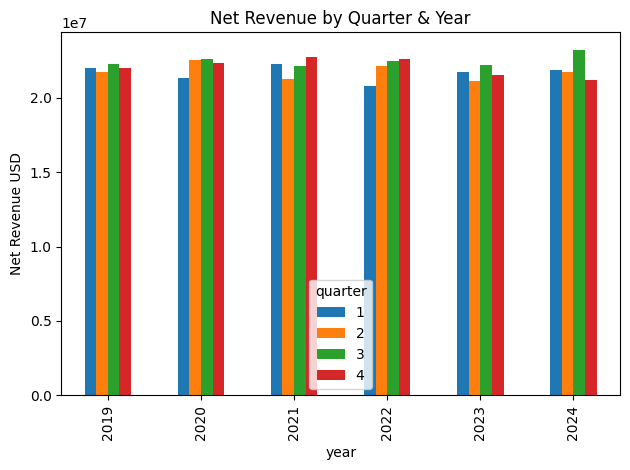

In [36]:
sales_q = fact_sales.merge(dim_date[['date_key', 'year', 'quarter']], on='date_key')
quarterly = sales_q.groupby(['year', 'quarter'])[['net_revenue', 'profit']].sum().round(2)
print(quarterly)

quarterly['net_revenue'].unstack().plot(kind='bar', title='Net Revenue by Quarter & Year')
plt.ylabel('Net Revenue USD')
plt.tight_layout()
plt.show()

### Q32. Is there a correlation between quality_score and lead_time_days in procurement?

Correlation Matrix:
                quality_score  lead_time_days
quality_score        1.000000        0.036758
lead_time_days       0.036758        1.000000


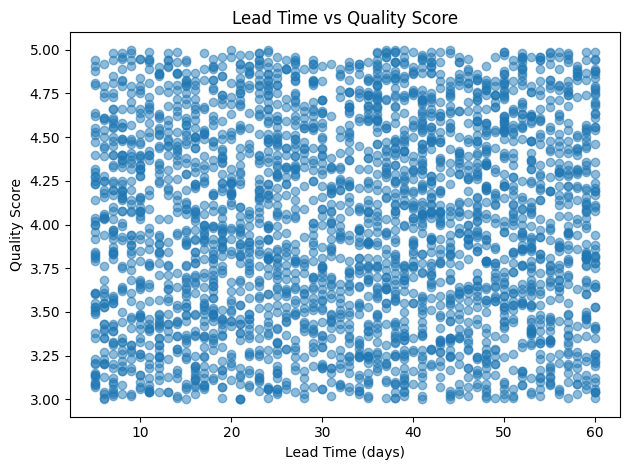

In [37]:
corr = fact_procurement[['quality_score', 'lead_time_days']].corr()
print('Correlation Matrix:')
print(corr)

plt.scatter(fact_procurement['lead_time_days'], fact_procurement['quality_score'], alpha=0.5)
plt.xlabel('Lead Time (days)')
plt.ylabel('Quality Score')
plt.title('Lead Time vs Quality Score')
plt.tight_layout()
plt.show()

### Q33. Which facility type has the highest production output and lowest defect rate?

               total_produced  avg_defect_rate
facility_type                                 
Assembly              1025674             2.52
Distribution          1939582             2.52
Manufacturing          970397             2.48
Warehouse             1002007             2.50


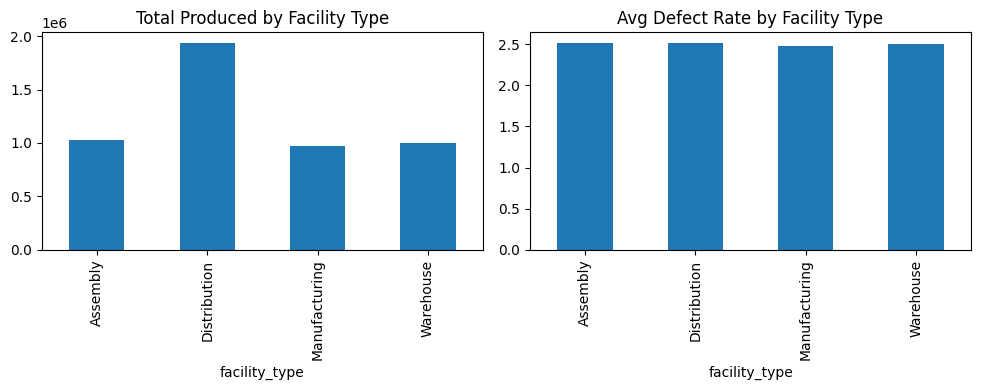

In [38]:
prod_factype = fact_production.merge(dim_facility[['facility_id', 'facility_type']], on='facility_id')
factype_summary = prod_factype.groupby('facility_type').agg(
    total_produced=('quantity_produced', 'sum'),
    avg_defect_rate=('defect_rate_pct', 'mean')
).round(2)
print(factype_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
factype_summary['total_produced'].plot(kind='bar', ax=axes[0], title='Total Produced by Facility Type')
factype_summary['avg_defect_rate'].plot(kind='bar', ax=axes[1], title='Avg Defect Rate by Facility Type')
plt.tight_layout()
plt.show()

### Q34. What is the weekend vs weekday sales comparison (revenue & orders)?

         total_orders  total_revenue
Weekday         71531   3.799401e+08
Weekend         28469   1.474613e+08


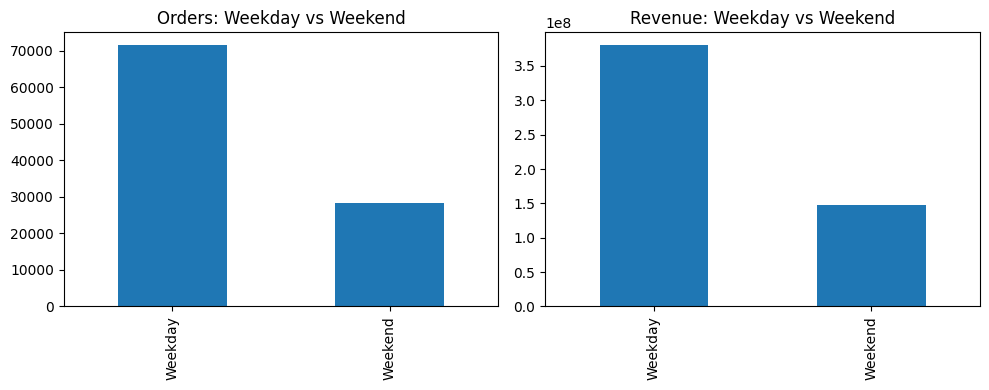

In [39]:
sales_wknd = fact_sales.merge(dim_date[['date_key', 'is_weekend']], on='date_key')
wknd_compare = sales_wknd.groupby('is_weekend').agg(
    total_orders=('sales_id', 'count'),
    total_revenue=('net_revenue', 'sum')
)
wknd_compare.index = ['Weekday', 'Weekend']
print(wknd_compare)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
wknd_compare['total_orders'].plot(kind='bar',   ax=axes[0], title='Orders: Weekday vs Weekend')
wknd_compare['total_revenue'].plot(kind='bar',  ax=axes[1], title='Revenue: Weekday vs Weekend')
plt.tight_layout()
plt.show()

### Q35. Which products have both high sales profit AND high defect rates? (Risk Products)

High Profit + High Defect Products: 3
           product_name  total_profit  avg_defect_rate
6         Standing Desk    46563080.0         2.612343
14         Circular Saw    11986832.0         2.562124
2   Mechanical Keyboard     7143900.0         2.625429


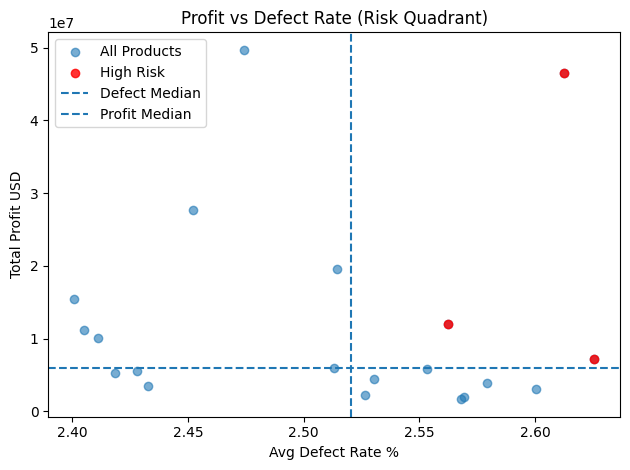

In [40]:
# Aggregate profit per product from sales
prod_profit = fact_sales.groupby('product_id')['profit'].sum().reset_index()
prod_profit.columns = ['product_id', 'total_profit']

# Aggregate defect rate per product from production
prod_defect = fact_production.groupby('product_id')['defect_rate_pct'].mean().reset_index()
prod_defect.columns = ['product_id', 'avg_defect_rate']

# Join both and add product name
risk_df = prod_profit.merge(prod_defect, on='product_id')
risk_df  = risk_df.merge(dim_product[['product_id', 'product_name']], on='product_id')

# High profit = above median, high defect = above median
profit_med = risk_df['total_profit'].median()
defect_med = risk_df['avg_defect_rate'].median()

risk_products = risk_df[
    (risk_df['total_profit'] > profit_med) &
    (risk_df['avg_defect_rate'] > defect_med)
].sort_values('total_profit', ascending=False)

print(f'High Profit + High Defect Products: {len(risk_products)}')
print(risk_products[['product_name', 'total_profit', 'avg_defect_rate']].head(10))

plt.scatter(risk_df['avg_defect_rate'], risk_df['total_profit'], alpha=0.6, label='All Products')
plt.scatter(risk_products['avg_defect_rate'], risk_products['total_profit'],
            color='red', alpha=0.8, label='High Risk')
plt.axvline(defect_med, linestyle='--', label='Defect Median')
plt.axhline(profit_med, linestyle='--', label='Profit Median')
plt.xlabel('Avg Defect Rate %')
plt.ylabel('Total Profit USD')
plt.title('Profit vs Defect Rate (Risk Quadrant)')
plt.legend()
plt.tight_layout()
plt.show()